# Emulators

Emulators are core components of the history matching algorithm. An emulator is a function that allows us to predict the output of a model for a set of input parameters, along with some uncertainty measures. An important characteristic of an emulator is that its execution time is much faster than the execution time of a model. The `emulators` module of our package contains some emulators. Here we describe how to use the emulators included in the `history_matching` package. 

## Libraries, global parameters, and initialization

The basic libraries for numerical analysis are used throughout the notebook, namely, numpy and pandas. We also use the `emulator` module from our library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import history_matching.emulators as emulators

%matplotlib inline




Loaded tensorflow-probability version 0.24.0.
Loaded tensorflow-probability version 0.24.0.


## Example scenarios

### Linear model (1D)

Let's define a linear model in 1 dimension. In its simplest form, this model receives a single scalar $x$
 and outputs a scalar $y$. This scalar is computed as $b_0 + b_1 x + \mathcal{N}(0, \sigma)$, with $b_0$, $b_1$, and $\sigma$ being hyper-parameters that, for all the purposes in this example, are constant (and unknown to an emulator).

We can implement this model as a function that applies to a set of inputs $\{x\}$. These inputs are defined as separate rows of an input dataframe `x`. Consequently, this function computes the corresponding outputs $\{y\}$ and returns them in an output dataframe.

In [66]:
def linear_model( x: pd.DataFrame(), b0=1, b1=2, sigma=7.5 ):
    """ 1-D linear model. Using the value of theta in each row of the
    input dataframe, the model computes outputs in an output dataframe 
    as  b0 + b1*x + mu,  with mu being drawn from a 0-mean normal 
    distribution with standard deviation sigma.
    """
    y = b0 + b1*x['x'] + np.random.normal( 0, sigma, len(x) )
    y = y.to_frame( name='out' )
    y.index = x.index
    return y

Now, let's see how this model works. We should be able to see the output as a noisy line.

<Axes: title={'center': 'Linear model'}, xlabel='x', ylabel='y'>

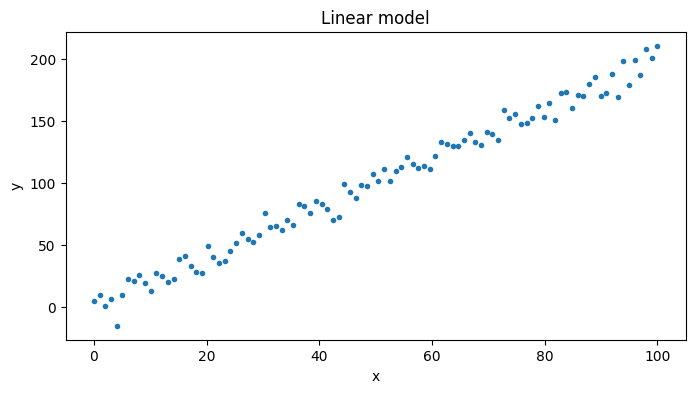

In [68]:
# Set model coefficients (i.e., hyperparameters)
b0_linear = -3
b1_linear = 8

# Get data points
xmin = 0
xmax = 100
n = 100
x = pd.DataFrame( { 'x' : np.linspace( xmin, xmax, n ) } )
y = linear_model(x)

# Draw plot
xy_linear = pd.concat( [x, y], axis=1 )
xy_linear.plot( title='Linear model', x='x', y='out', ylabel='y', legend=False, style='.', figsize=(8,4))

### Linear model (4D)

Lt'' extend our linear model to include 4 independent parameters. This will allow us to check the functionality of estimators in scenarios with multiple dimensions.ataframe.

In [70]:
def linear_model_4d( x: pd.DataFrame(), b0=1, b1=2, b2=3, b3=4, b4=5, sigma=7.5 ):
    """ 4-D linear model. Using the value of theta in each row of the
    input dataframe, the model computes outputs in an output dataframe 
    as  b0 + b1*x1 + b2*x2 + b3*x3 + b4*x4 + mu,  with mu being drawn 
    from a 0-mean normal distribution with standard deviation sigma.
    """
    y = b0 + b1*x['x_1'] + b2*x['x_2']    \
           + b3*x['x_3'] + b4*x['x_4']    \
           + np.random.normal( 0, sigma, len(x) )
    y = y.to_frame( name='out' )
    y.index = x.index
    return y

Let's quickly check how our model works:

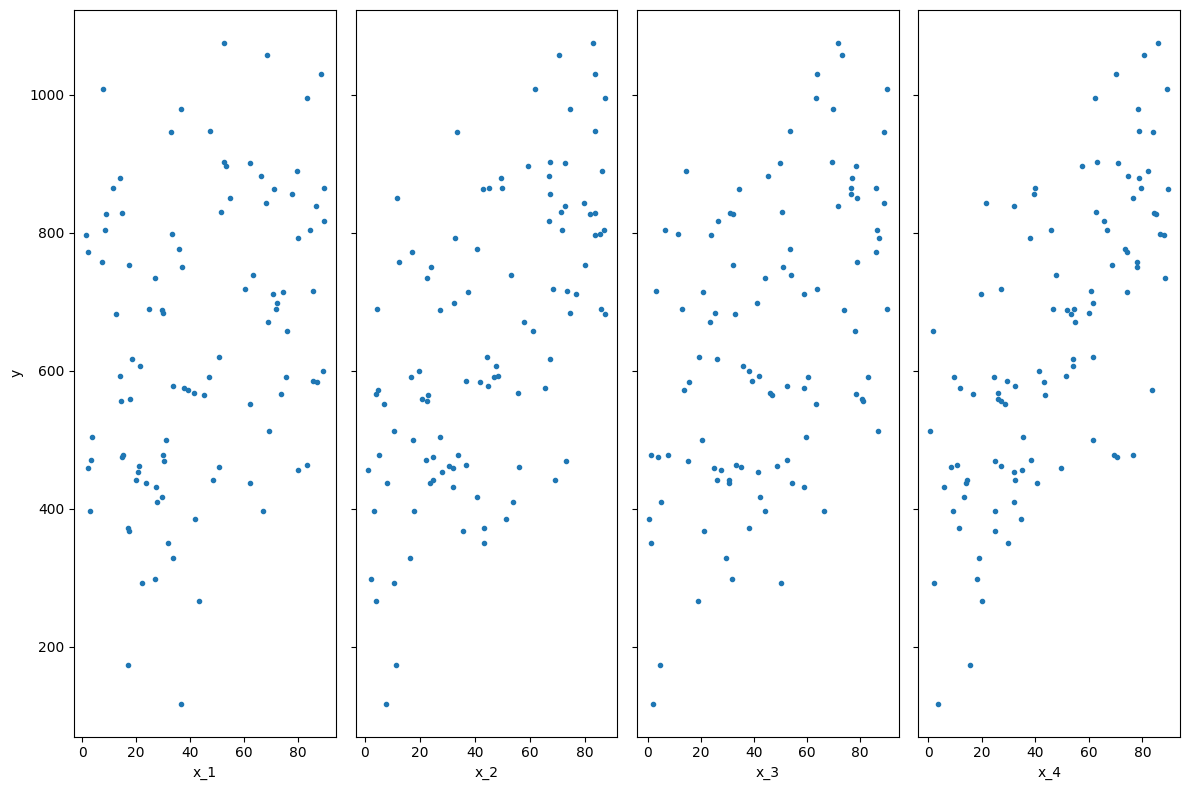

In [73]:
# Set model coefficients (i.e., hyperparameters)
b0_4d = -30
b1_4d =  8
b2_4d =  100
b3_4d =  5000
b4_4d = -25

# Get data points
xmin = 0
xmax = 100
n = 100
x = pd.DataFrame( np.random.uniform( 0, 90, size=(n,4)), columns=['x_1', 'x_2', 'x_3', 'x_4'] )
y = linear_model_4d(x)

# Draw plot
xy_4d = pd.concat( [x, y], axis=1 )
fig_4d, axs_4d = plt.subplots( 1, 4, figsize=(12,8), sharey=True )
xy_4d.plot( x='x_1', y='out', style='.', legend=False, ax=axs_4d[0] )
xy_4d.plot( x='x_2', y='out', style='.', legend=False, ax=axs_4d[1] )
xy_4d.plot( x='x_3', y='out', style='.', legend=False, ax=axs_4d[2] )
xy_4d.plot( x='x_4', y='out', style='.', legend=False, ax=axs_4d[3] )
axs_4d[0].set_ylabel( 'y' )
fig_4d.tight_layout()

### Poisson distribution

We can generate Poisson-distributed data using the following model:
$$
\ln( \lambda_i ) = b_0 + b_1 x_i;
$$
$$
y_i \sim \text{Poisson}( \lambda_i ), 
$$
where $b_0$ and $b_1$ are the model coefficients, $x_i \in \{x_0, x_1, \ldots, x_{n-1} \}$ is an input to the model, and $y_i$ is its corresponding model output.

In [49]:
def poisson_model( x: pd.DataFrame(), b0=1, b1=2 ):
    """ Draw data from a Poisson distribution.
    """
    ln_lambda = b0 + b1*x
    lambda_coeff = np.exp( ln_lambda )
    y = np.random.poisson( lambda_coeff )
    y = pd.DataFrame( {'out': y.flatten()}, index=x.index )
    return y

A set of data drawn using this model will look like the following:

<Axes: xlabel='x', ylabel='y'>

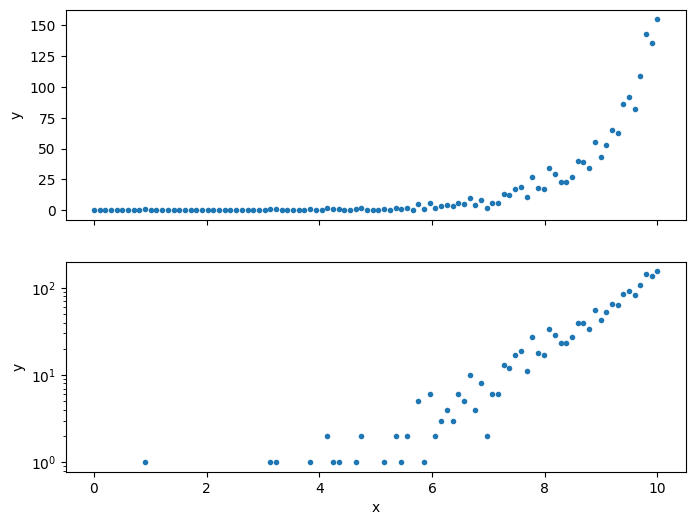

In [63]:
# Set model coefficients
b0_poisson = -5
b1_poisson = 1

# Get data points
xmin = 0
xmax = 10
n = 100
x = pd.DataFrame( { 'x' : np.linspace( xmin, xmax, n ) } )
y = poisson_model( x, b0_poisson, b1_poisson )

# Draw figure
xy_poisson = pd.concat( [x, y], axis=1 )
fig_poisson, axs_poisson = plt.subplots( 2, 1, sharex=True, figsize=(8,6) )
xy_poisson.plot( x='x', y='out', style='.', xlabel='x', ylabel='y', logy=False, legend=False, ax=axs_poisson[0] )
xy_poisson.plot( x='x', y='out', style='.', xlabel='x', ylabel='y', logy=True , legend=False, ax=axs_poisson[1] )

## Working with a linear model emulator

One of the most basic emulators is the linear regression emulator. This emulator is defined by the `emulators.LinearModel` class.s:

### Instantiating and training the emulator


We can train our emulator by instantiating it with some input data (such as the one created above using the linear model), and then calling th`e train`() method, as follows:

In [6]:
linear_emulator = emulators.LinearModel(x, y)
linear_emulator.train()

We can get information about the emulator object by using the `info()` method:

In [7]:
linear_emulator.info()

... General information:
      Number of parameters =  1
      Number of samples (total) =  100
      Number of training samples =  75
      Number of testing samples =  25

... Emulator configuration:
      coefficients:  [[1.98170013]]
      intercept   :  [1.87068449]

      This emulator has not been tested yet


Note that the general information above contains a default number of testing and training samples. We can explicitly indicate what fraction of the data to use for testing by setting the `test_fraction` argument when instantiating the emulator object. For example, if we want to use 50% of the data for testing, we can set our emulator as `linear_emulator = emulators.LinearModel(x, y, test_fraction=0.5).`s:

### Predicting outputs

Once we have trained our emulator, we can use it for predicting some outputs:

In [8]:
x_predict = pd.DataFrame( { 'theta' : np.random.rand(n)*(theta_max-theta_min) + theta_min })
y_predict = linear_emulator.predict( x_predict )
print( y_predict.head() )

        value        low        high
0   10.119628 -88.839150  109.078406
1   13.523474 -85.435304  112.482252
2   47.646057 -51.312721  146.604835
3   69.728390 -29.230388  168.687168
4  108.089354   9.130576  207.048132


Let's compare the training and predicted data:

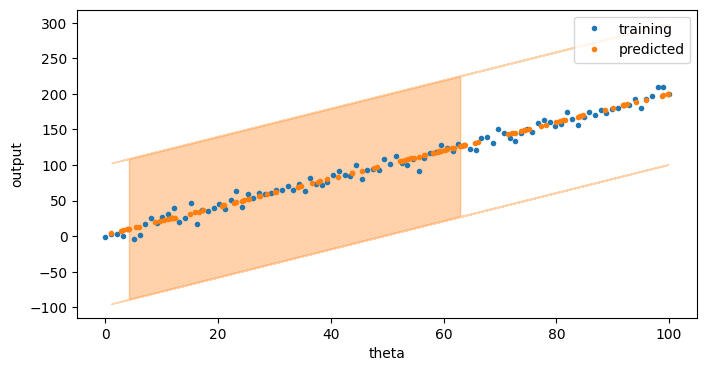

In [9]:
fig_pred, ax_pred = plt.subplots(1, 1, figsize=(8,4) )
xy = pd.DataFrame( { 'theta'    : x['theta'].values ,
                     'training' : y['out'].values
                    } )
xy = pd.concat( [ xy, pd.DataFrame( { 'theta' : x_predict['theta'].values,
                                      'predicted' : y_predict['value'].values
                                     } ) 
                 ], ignore_index=True )
xy.plot(x='theta', style='.', ylabel='output', ax=ax_pred )

ax_pred.fill_between( x_predict['theta'].values, 
                      y_predict['low'].values,
                      y_predict['high'].values,
                      color = 'tab:orange',
                      alpha = 0.35
                     )

In addition to the predicted value, the `predict()` method gives us lower and upper uncertainty bounds. In this emulator, those bounds are defined by default by the 5th and 95th percentiles of the normal distribution centered at the predicted value, and with variance estimated from the training data. We can change these percentiles by modifying some arguments in the call for predicting outputs:

In [10]:
y_predict_new_quantiles = linear_emulator.predict( x_predict, qlow=0.25, qhi=0.75 )
print( y_predict_new_quantiles.head() )

        value        low        high
0   10.119628 -30.459473   50.698729
1   13.523474 -27.055627   54.102575
2   47.646057   7.066956   88.225158
3   69.728390  29.149289  110.307491
4  108.089354  67.510253  148.668455


### Evaluating the performance of our emulator

We can run some diagnostics and evaluate the performance of our emulator using the` test(`) method:

In [11]:
linear_emulator.test()

A summary of the performance results can now be seen when calling the `info()` method:

In [12]:
linear_emulator.info()

... General information:
      Number of parameters =  1
      Number of samples (total) =  100
      Number of training samples =  75
      Number of testing samples =  25

... Emulator configuration:
      coefficients:  [[1.98170013]]
      intercept   :  [1.87068449]

... Performance results:
      MSE =  30.554754774616388
      R2 =  nan


We can get more detailed information by plotting diagnostics. These are a set of figures that can provide some deeper information that the one that is quantified in the summarized performance results.

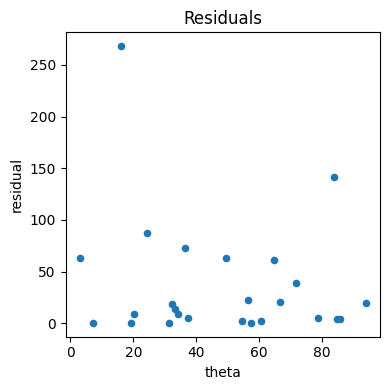

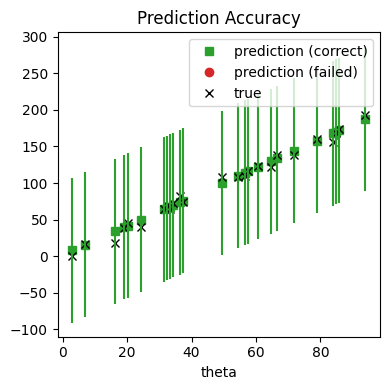

In [13]:
linear_emulator.plot_diagnostics()

### Computing impausibilty measures

We can compute the implausibility measure used in the history matching algorithm by calling the `get_implausibility()` method:

In [14]:
target_value = 100
target_var = 7.5
x_imp = pd.DataFrame( { 'theta' : np.linspace( 0, 100, 50 ) } )

linear_model_implausibility = linear_emulator.get_implausibility( x_imp, target_value, target_var )

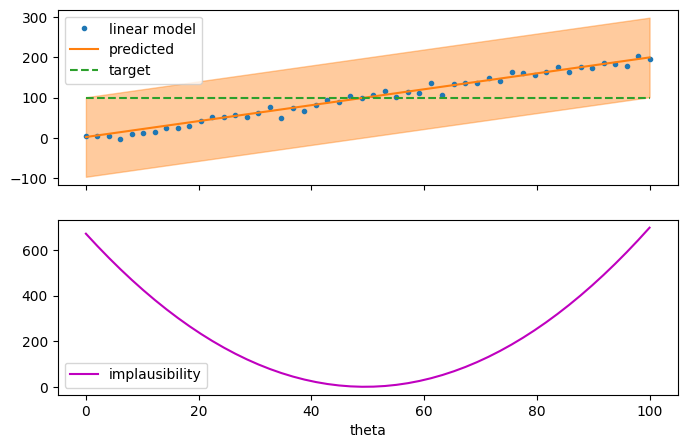

In [15]:
fig_imp, axs_imp = plt.subplots(2, 1, figsize=(8,5), sharex=True )


lm_imp = pd.DataFrame( { 'theta'    : x_imp['theta'].values,
                         'linear model' : linear_model(x_imp)['out'].values,
                         'predicted'    : linear_emulator.predict(x_imp['theta'])['value'].values,
                         'target'       : target_value,
                         'implausibility' : linear_model_implausibility
                    } )

lm_imp.plot( x='theta', y=['linear model', 'predicted', 'target'], style=['.','-','--'], ax=axs_imp[0] )
lm_imp.plot( x='theta', y='implausibility', c='m', ax=axs_imp[1] )

axs_imp[0].fill_between( lm_imp['theta'], 
                     linear_emulator.predict(x_imp['theta'])['low'].values,
                     linear_emulator.predict(x_imp['theta'])['high'].values,
                     color = 'tab:orange',
                     alpha = 0.4
                    )

We can also use an emulator function to plot implausibility:

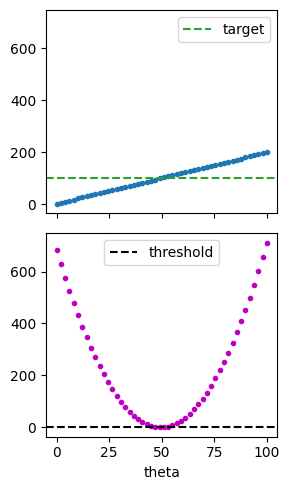

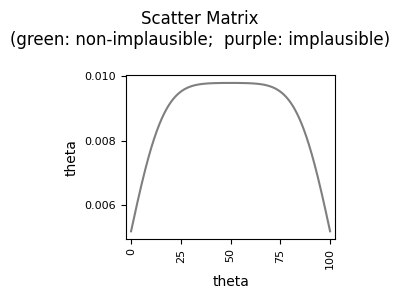

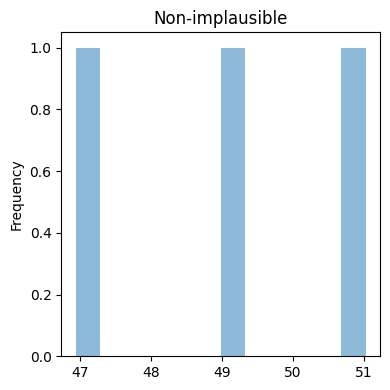

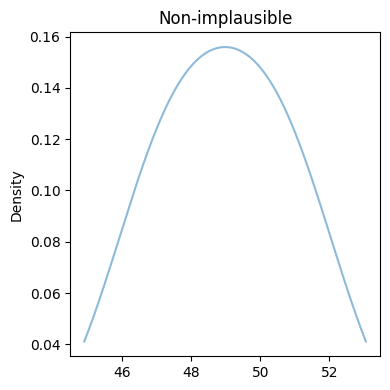

In [16]:
linear_emulator.plot_implausibility( x_imp, target_value )

### Linear emulator with multiple parameters

Let's quickly evaluate how the linear emulator work when we have multiple parameters. In this case, we will use the [linear model (4D) model](#Linear-model-(4D)) described above.

We begin by training our emulator:

In [17]:
linear4d_emulator = emulators.LinearModel(x4d, y4d)
linear4d_emulator.train()
linear4d_emulator.info()

... General information:
      Number of parameters =  4
      Number of samples (total) =  100
      Number of training samples =  300
      Number of testing samples =  100

... Emulator configuration:
      coefficients:  [[2.03122985 3.0703592  4.01515427 4.99279974]]
      intercept   :  [-3.71241697]

      This emulator has not been tested yet


Now we test the emulator to see obtain some accuracy metrics:

In [18]:
linear4d_emulator.test()
linear4d_emulator.info()

... General information:
      Number of parameters =  4
      Number of samples (total) =  100
      Number of training samples =  300
      Number of testing samples =  100

... Emulator configuration:
      coefficients:  [[2.03122985 3.0703592  4.01515427 4.99279974]]
      intercept   :  [-3.71241697]

... Performance results:
      MSE =  36.64388018490695
      R2 =  nan


And finally, we can use some diagnostics to evaluate its performance:

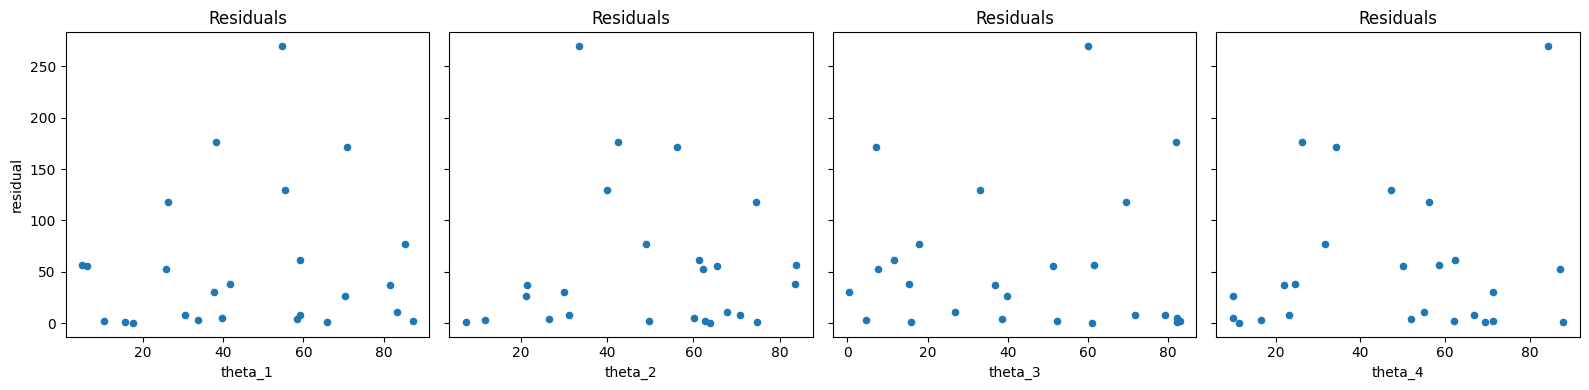

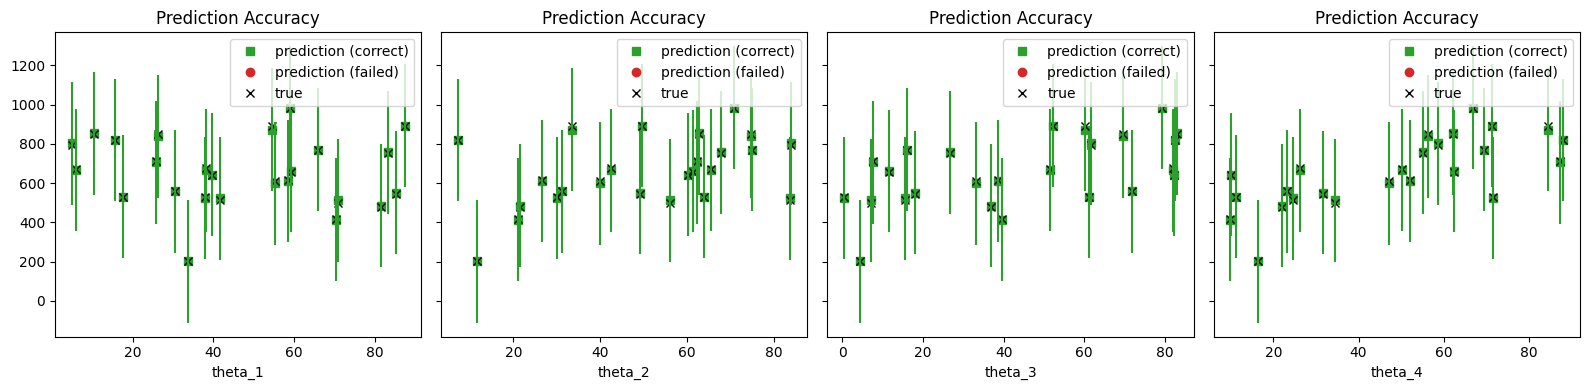

In [19]:
linear4d_emulator.plot_diagnostics()

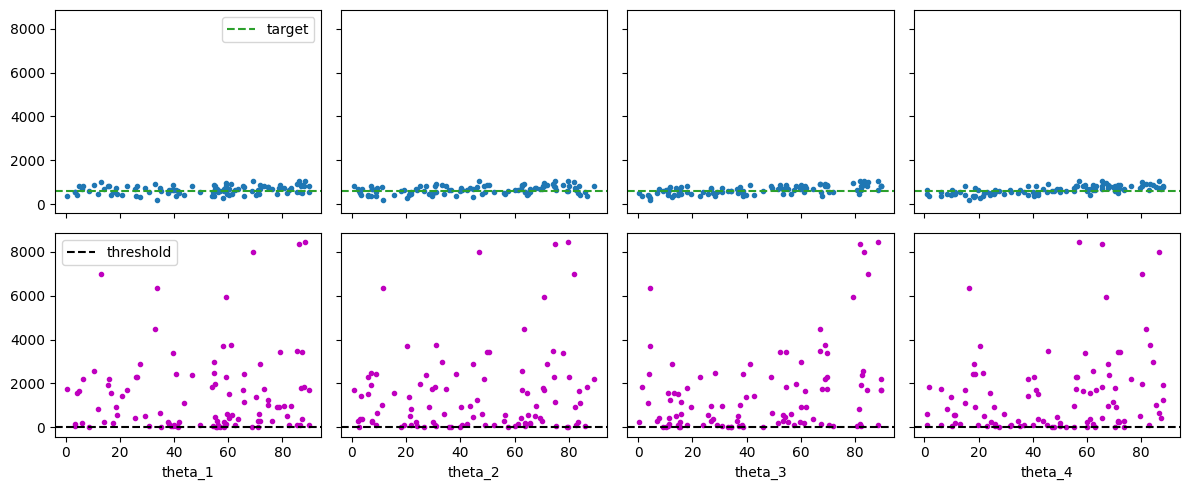

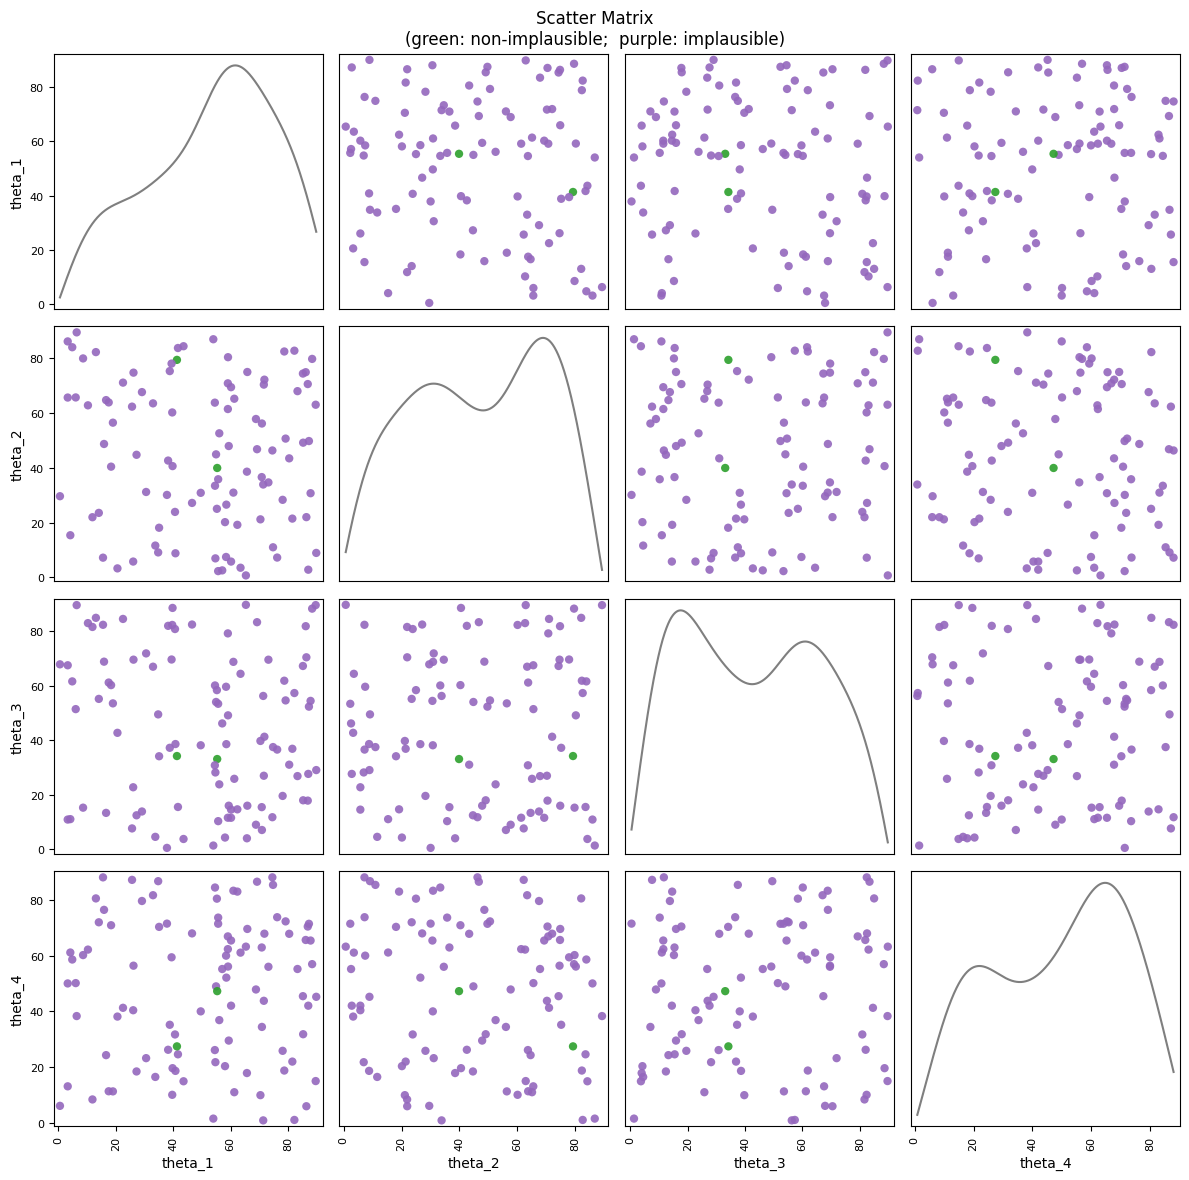

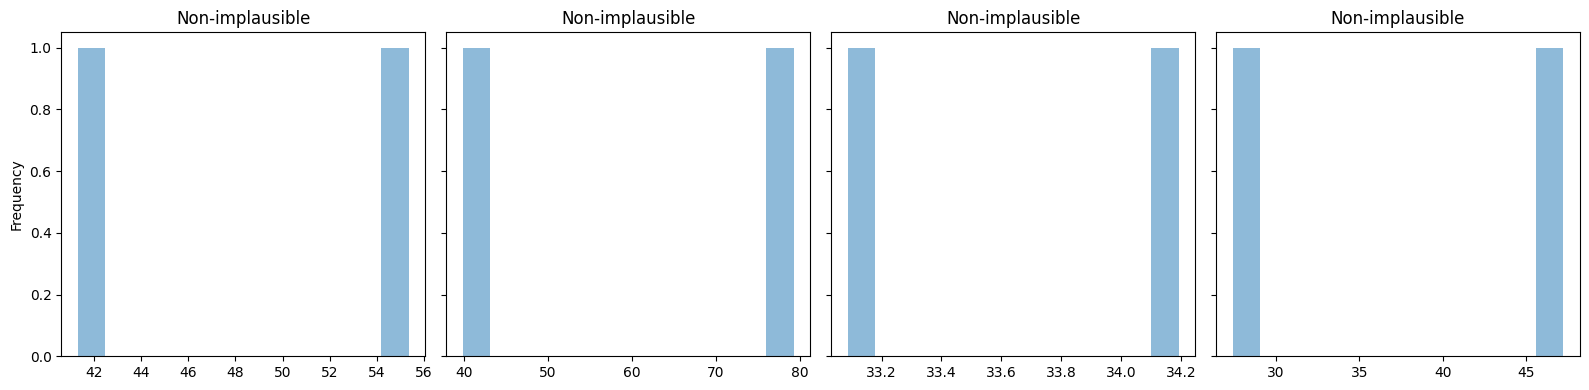

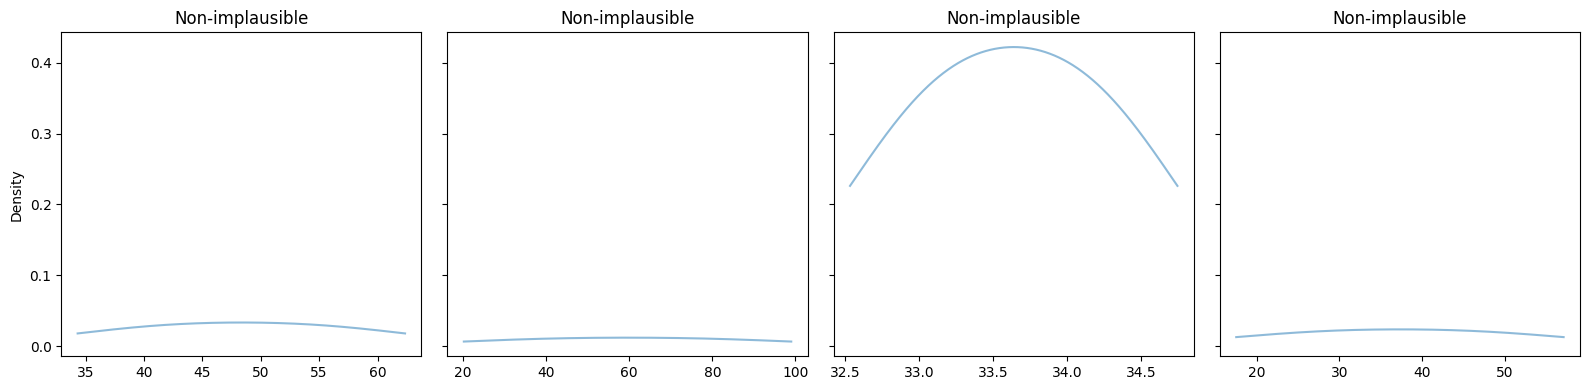

In [20]:
linear4d_emulator.plot_implausibility( x4d, 600 )

### Linear emulator with nonlinear parameters